# Phase 6 — Hyperparameter Tuning

**Objective:** Improve LightGBM performance using Bayesian optimization (Optuna)
rather than exhaustive grid search.

Loads the train/val splits, runs a 50-trial Optuna study, trains the final tuned
model, and saves it (`final_lgb_model.txt`) plus the convergence chart for the report.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import lightgbm as lgb
import optuna
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

X_train = pd.read_parquet("exp_files/X_train.parquet")
X_val = pd.read_parquet("exp_files/X_val.parquet")
y_train = pd.read_parquet("exp_files/y_train.parquet")["CHURN"]
y_val = pd.read_parquet("exp_files/y_val.parquet")["CHURN"]

optuna.logging.set_verbosity(optuna.logging.WARNING)

## Define the Optuna search space and objective function

In [2]:
def objective(trial):
    # 1. Define the hyperparameter search space
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "verbose": -1,
        "seed": 42,
        # "is_unbalance": True,
        "feature_pre_filter": False,
        # Hyperparameters to tune
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63),
        "max_depth": trial.suggest_int("max_depth", 4, 8),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": 1,
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),  # L1 regularization
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True), # L2 regularization
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 10.0)  # Adjust for class imbalance
    }
    
    # 2. Re-initialize dataset pointers for this trial
    dtrain = lgb.Dataset(X_train, label=y_train)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)
    
    # 3. Train with early stopping
    model = lgb.train(
        params,
        train_set=dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(stopping_rounds=30, verbose=False)
        ]
    )
    
    # 4. Predict on validation set and evaluate performance
    preds = model.predict(X_val, num_iteration=model.best_iteration)
    score = roc_auc_score(y_val, preds)
    
    # Return the validation score to Optuna
    return score

## Run the study — 50 trials, TPE sampler

In [3]:
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))

print("Starting Bayesian Optimization via Optuna...")
study.optimize(objective, n_trials=100, show_progress_bar=True)

# Print the final results
print("\n=== OPTIMIZATION COMPLETE ===")
print(f"Best Validation AUC: {study.best_value:.5f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Starting Bayesian Optimization via Optuna...


  0%|          | 0/100 [00:00<?, ?it/s]


=== OPTIMIZATION COMPLETE ===
Best Validation AUC: 0.98477
Best Hyperparameters:
  learning_rate: 0.04320550384412632
  num_leaves: 26
  max_depth: 6
  feature_fraction: 0.7491423121735307
  bagging_fraction: 0.6966686471169804
  min_child_samples: 137
  reg_alpha: 9.501559539041462
  reg_lambda: 0.12103952031319541
  scale_pos_weight: 1.4441178038783848


## Convergence chart

Shows validation AUC across trials with a running-best line — proves the search
actually converged rather than wandering randomly.

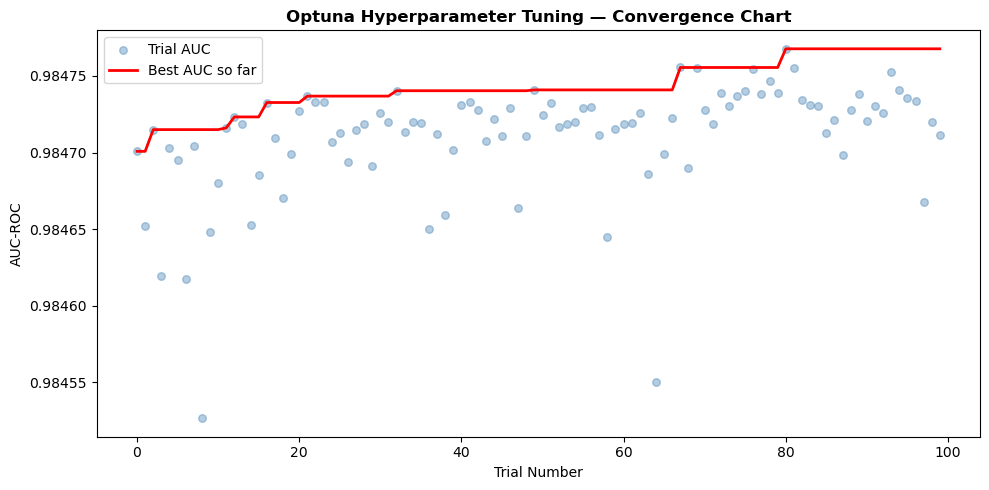

In [4]:
trial_numbers = [t.number for t in study.trials]
trial_values = [t.value for t in study.trials]

running_best = []
current_best = 0
for v in trial_values:
    if v > current_best:
        current_best = v
    running_best.append(current_best)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(trial_numbers, trial_values, alpha=0.4, color='steelblue', label='Trial AUC', s=30)
ax.plot(trial_numbers, running_best, color='red', linewidth=2, label='Best AUC so far')
ax.set_xlabel("Trial Number")
ax.set_ylabel("AUC-ROC")
ax.set_title("Optuna Hyperparameter Tuning — Convergence Chart", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("convergence_chart.png", dpi=150)
plt.show()

## Train the final model with the best parameters found

In [5]:
fixed_params = {
    "objective": "binary",
    "metric": "auc",
    "random_state": 42,
    "n_jobs": -1,          # Use all available CPU cores
    "verbose": -1          # Suppress unnecessary warning outputs
}

# Merge dictionaries — combines fixed settings with Optuna's winning hyperparameters
final_params = fixed_params | study.best_params

# Create native LightGBM training datasets
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# Train using dictionary unpacking
final_lgb_model = lgb.train(
    params=final_params,
    train_set=train_data,
    num_boost_round=2000,   # Set high, early stopping will save the best iteration
    valid_sets=[train_data, valid_data],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

Training until validation scores don't improve for 50 rounds
[50]	training's auc: 0.985177	valid_1's auc: 0.984582
[100]	training's auc: 0.985445	valid_1's auc: 0.984733
[150]	training's auc: 0.98559	valid_1's auc: 0.98474
Early stopping, best iteration is:
[127]	training's auc: 0.985536	valid_1's auc: 0.984749


In [6]:
import polars as pl

test_df = pl.read_parquet("exp_files/test_df.parquet")
test_users = pl.read_parquet("exp_files/test_users.parquet")
X_test = test_df.drop('ACCOUNT_ID').to_pandas()

# Generate continuous probability outcomes (0.0 to 1.0) for the competition submission
test_predictions = final_lgb_model.predict(X_test, num_iteration=final_lgb_model.best_iteration)

# Build submission DataFrame
submission = pl.DataFrame({
    "ACCOUNT_ID": test_df["ACCOUNT_ID"],
    "CHURN_PROB": test_predictions
})

USER_COL = "ACCOUNT_ID"
final_submission = test_users.join(submission, on=USER_COL, how='left')
print("\nSubmission Preview:")
print(final_submission.head())
final_submission.write_csv('output/tuned_predictions.csv')


Submission Preview:
shape: (5, 2)
┌──────────────┬────────────┐
│ ACCOUNT_ID   ┆ CHURN_PROB │
│ ---          ┆ ---        │
│ str          ┆ f64        │
╞══════════════╪════════════╡
│ CUST00074385 ┆ 0.995964   │
│ CUST00290073 ┆ 0.000725   │
│ CUST00247934 ┆ 0.001868   │
│ CUST00314276 ┆ 0.283696   │
│ CUST00522755 ┆ 0.43784    │
└──────────────┴────────────┘


## Before / after comparison table

In [7]:
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

def precision_recall_at_k(y_true, y_scores, k_pct=0.10):
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)
    n = len(y_true)
    k = max(1, int(n * k_pct))
    top_k_idx = y_scores.argsort()[::-1][:k]
    precision_at_k = y_true[top_k_idx].mean()
    recall_at_k = y_true[top_k_idx].sum() / y_true.sum()
    return precision_at_k, recall_at_k

tuned_preds = final_lgb_model.predict(X_val, num_iteration=final_lgb_model.best_iteration)
tuned_auc = roc_auc_score(y_val, tuned_preds)
tuned_ap = average_precision_score(y_val, tuned_preds)
tuned_p10, tuned_r10 = precision_recall_at_k(y_val, tuned_preds, 0.10)

print(f"Default AUC: {study.trials[0].value:.4f}  →  Tuned AUC: {study.best_value:.4f}  "
      f"(+{study.best_value - study.trials[0].value:.4f})")
print(f"Tuned model — AUC: {tuned_auc:.4f}, AP: {tuned_ap:.4f}, "
      f"P@10%: {tuned_p10:.4f}, R@10%: {tuned_r10:.4f}")

Default AUC: 0.9847  →  Tuned AUC: 0.9848  (+0.0001)
Tuned model — AUC: 0.9847, AP: 0.9226, P@10%: 0.9110, R@10%: 0.7186


In [8]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

cv_params = fixed_params | study.best_params

X_all = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_all = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_all))
test_preds = np.zeros(len(X_test)) if "X_test" in globals() else None
fold_models = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_all, y_all), start=1):
    X_tr, X_val_fold = X_all.iloc[train_idx], X_all.iloc[valid_idx]
    y_tr, y_val_fold = y_all.iloc[train_idx], y_all.iloc[valid_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dvalid = lgb.Dataset(X_val_fold, label=y_val_fold, reference=dtrain)

    model = lgb.train(
        params=cv_params,
        train_set=dtrain,
        num_boost_round=2000,
        valid_sets=[dvalid],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    fold_models.append(model)

    oof_preds[valid_idx] = model.predict(X_val_fold, num_iteration=model.best_iteration)

    if test_preds is not None:
        test_preds += model.predict(X_test, num_iteration=model.best_iteration) / skf.n_splits

oof_auc = roc_auc_score(y_all, oof_preds)
print(f"5-fold CV OOF AUC: {oof_auc:.4f}")

if test_preds is not None and "test_df" in globals():
    submission_cv = pd.DataFrame({
        "ACCOUNT_ID": test_df["ACCOUNT_ID"].to_list(),
        "CHURN_PROB": test_preds
    })
    submission_cv.to_csv("output/tuned_5fold_ensemble_predictions.csv", index=False)
    print("Saved output/tuned_5fold_ensemble_predictions.csv")

5-fold CV OOF AUC: 0.9850
Saved output/tuned_5fold_ensemble_predictions.csv


## Save the tuned model for downstream notebooks (explainability)

In [9]:
final_lgb_model.save_model("exp_files/final_lgb_model.txt")
print("Saved final_lgb_model.txt")

Saved final_lgb_model.txt


## Next notebook

Continue to **`07_explainability.ipynb`**, which loads `final_lgb_model.txt`
and computes SHAP values.